In [1]:
import pandas as pd
df = pd.read_csv('Breatscancer_dataset2.csv')
df.head()

,ID,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,1,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,0
1,2,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,0
2,3,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,0
3,4,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,0
4,5,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,0


In [2]:
df.isnull().sum()

ID                0
Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64

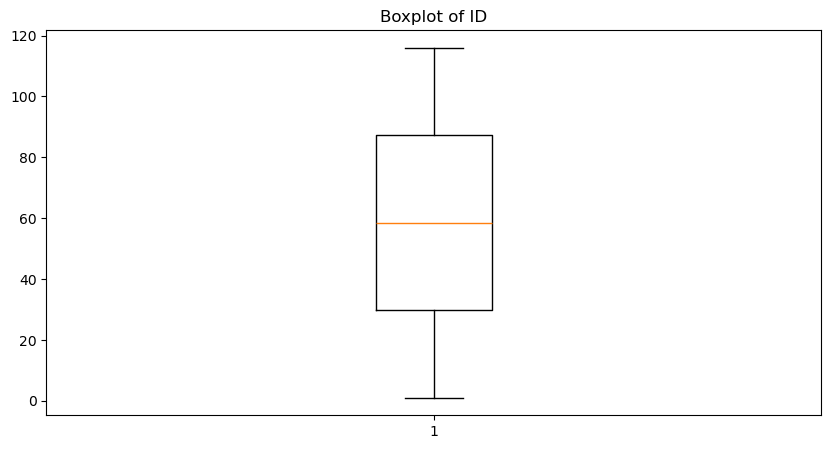

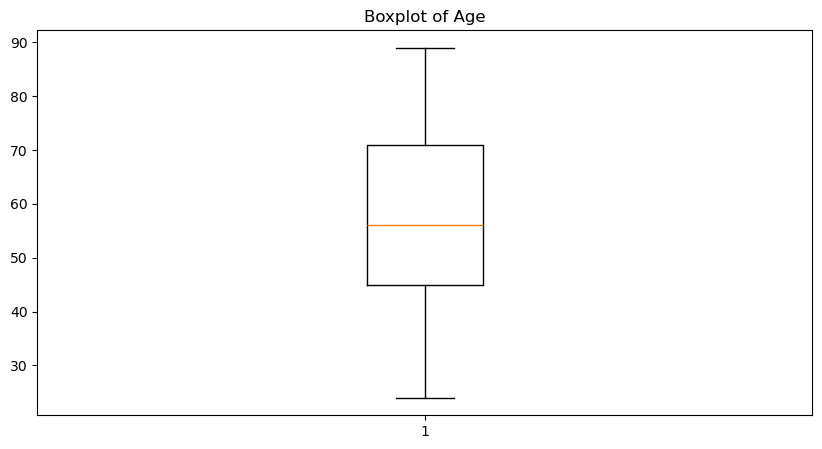

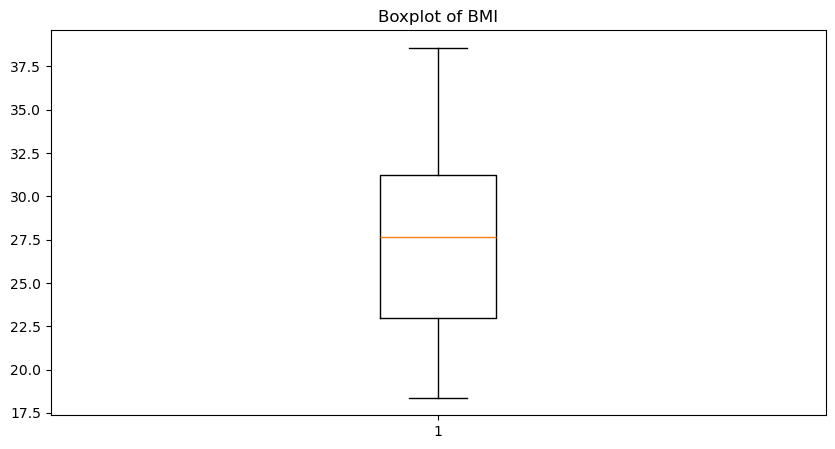

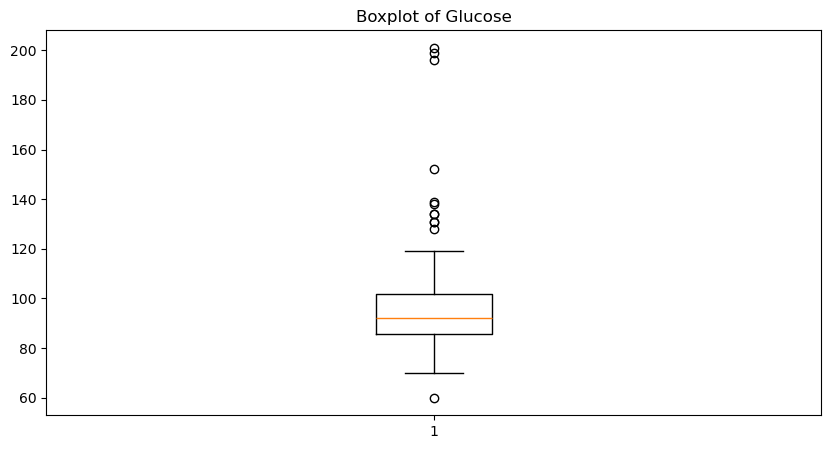

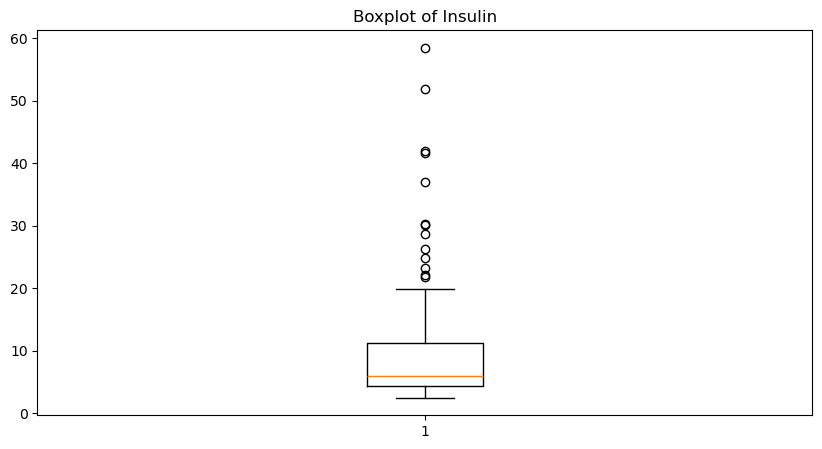

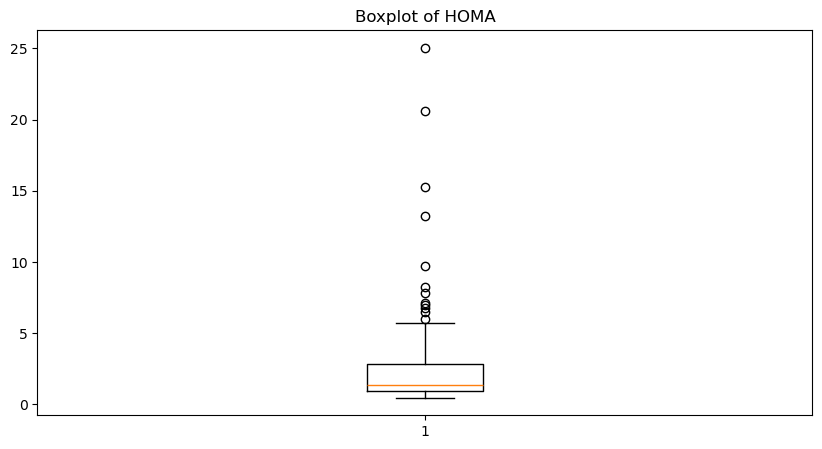

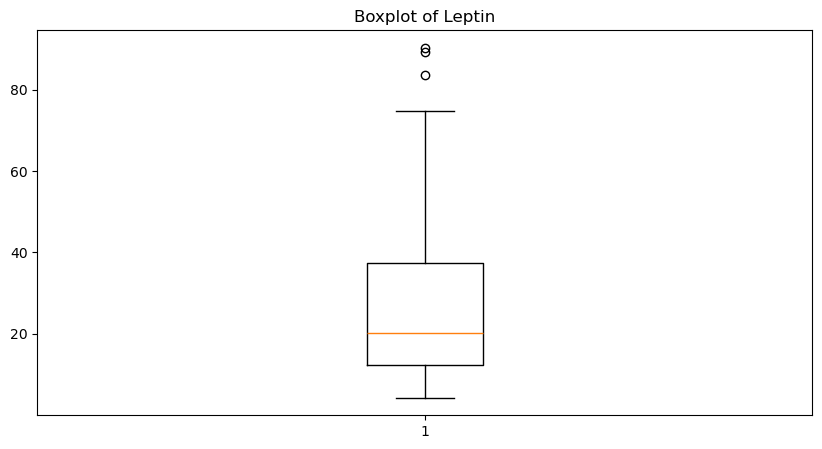

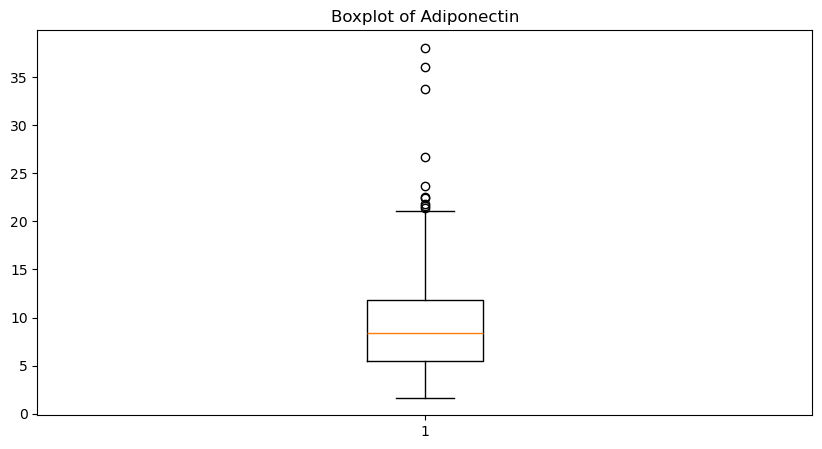

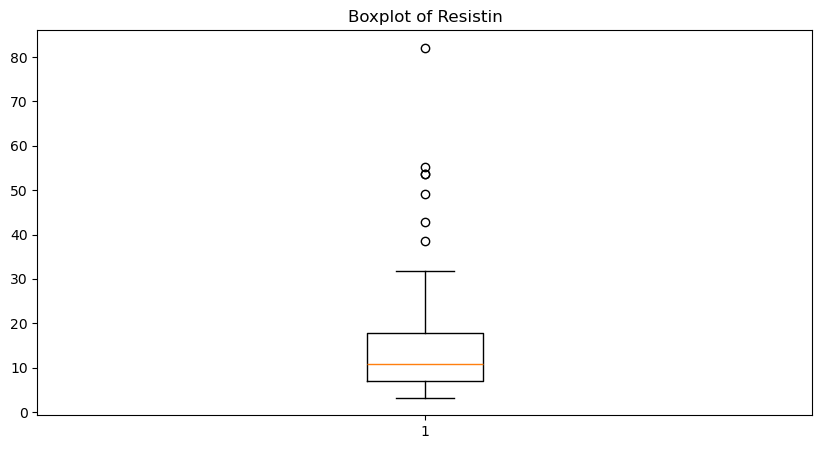

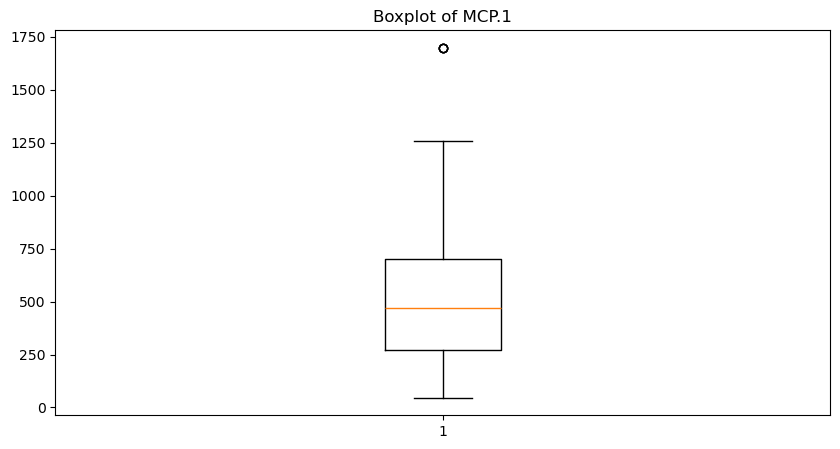

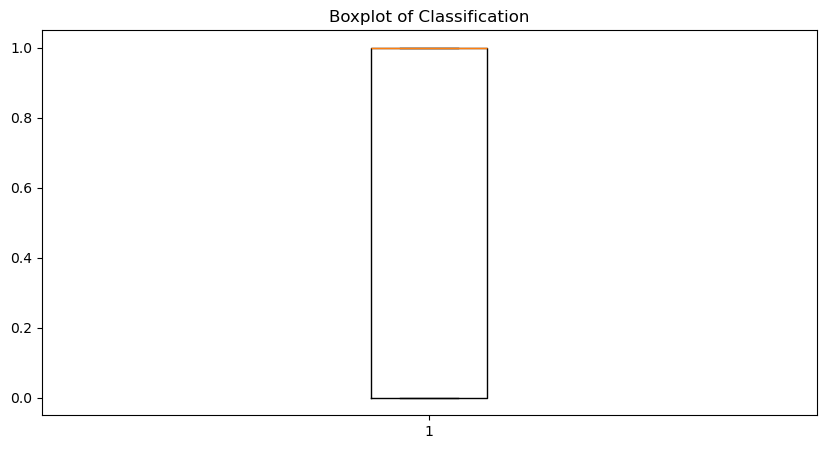

In [3]:
#detecting the outliers in all the columns
import matplotlib.pyplot as plt
for column in df.columns:
    plt.figure(figsize=(10, 5))
    plt.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()


In [4]:
outliers = {'Resistin','Adiponectin','MCP.1','Leptin','Insulin','Glucose','HOMA'}
for column in outliers:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].apply(lambda x: x if lower_bound <= x <= upper_bound else None)


In [5]:
df.isnull().sum()

ID                 0
Age                0
BMI                0
Glucose           12
Insulin           13
HOMA              12
Leptin             3
Adiponectin       10
Resistin           7
MCP.1              4
Classification     0
dtype: int64

In [6]:
#filling the null values with median
for column in df.columns:
    median_value = df[column].median()
    df[column].fillna(median_value, inplace=True)
df.isnull().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_7116\2657159748.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(median_value, inplace=True)


ID                0
Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64

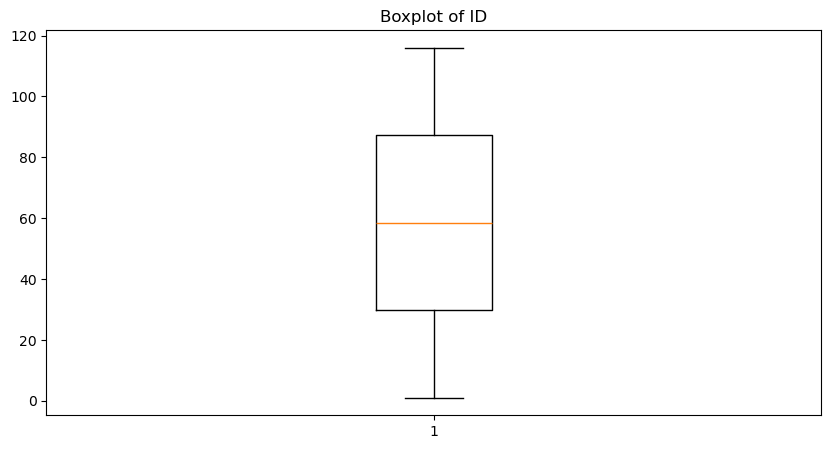

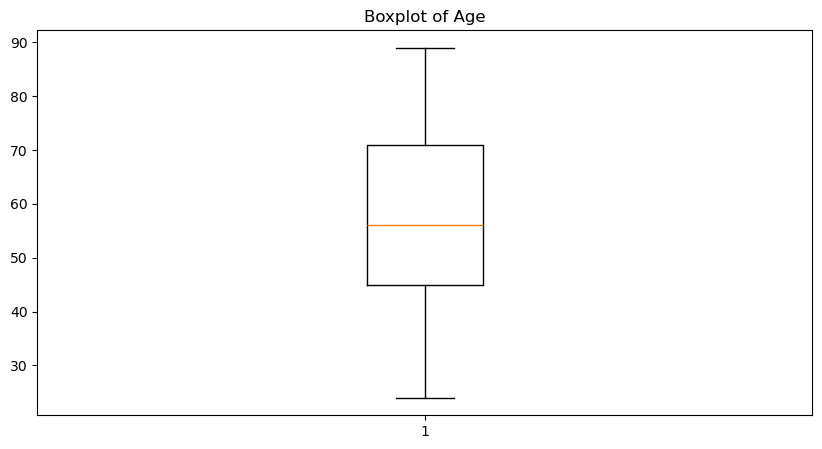

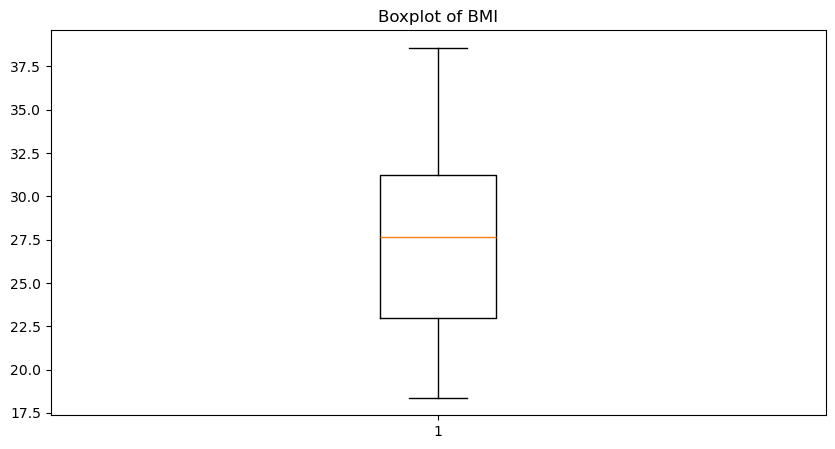

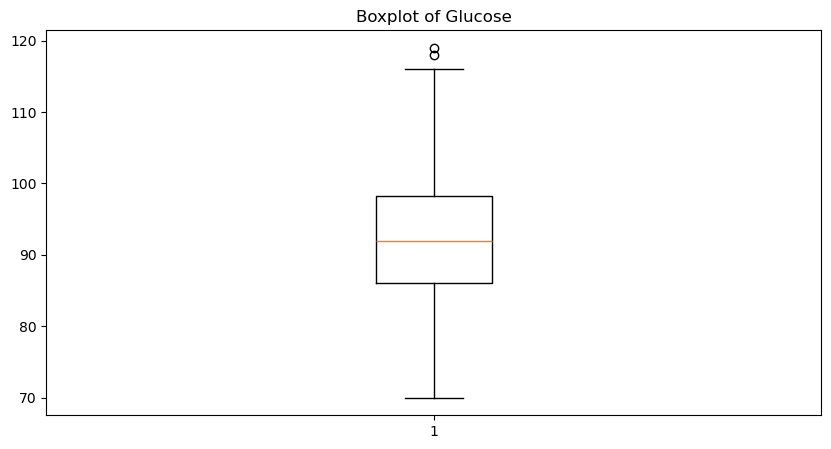

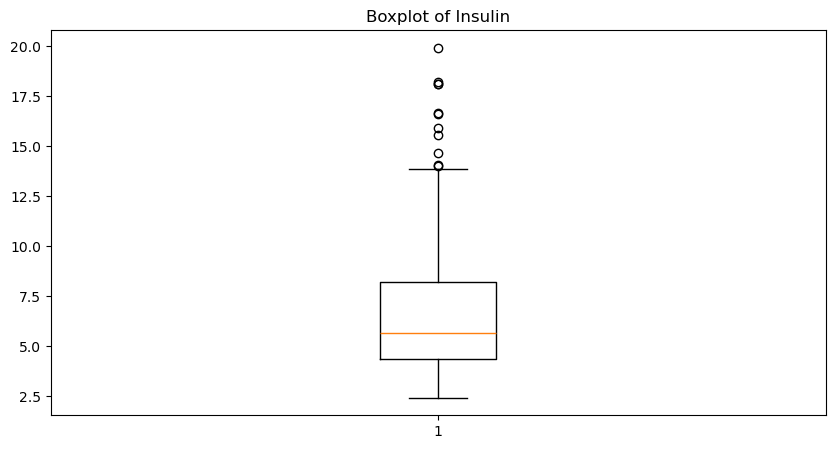

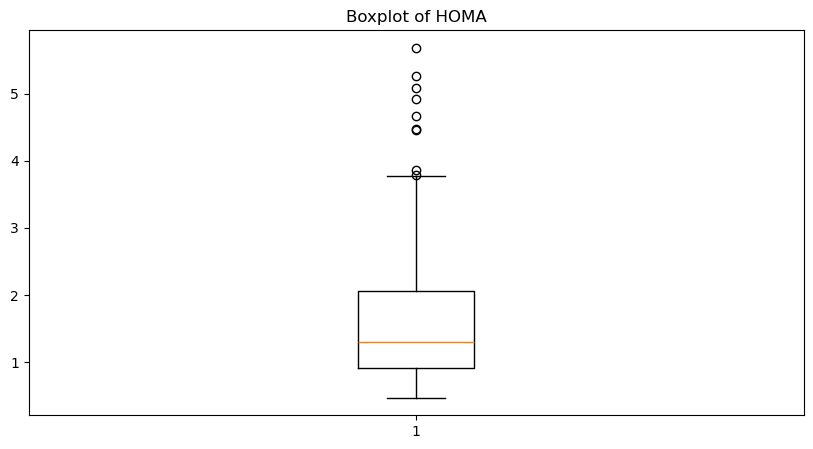

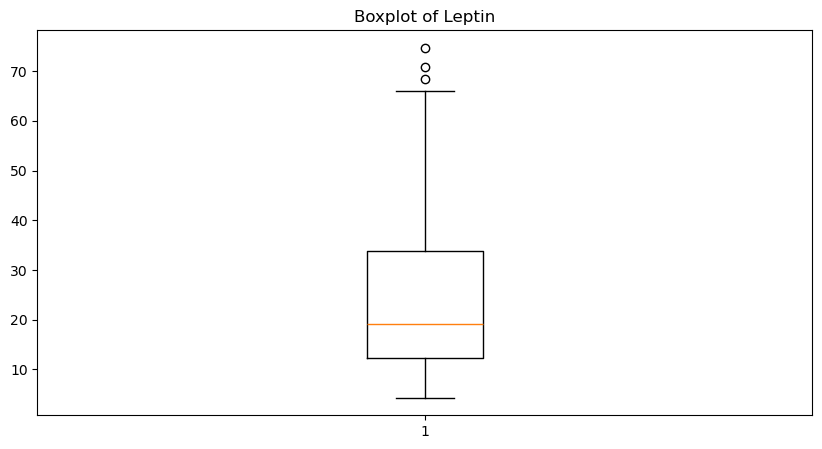

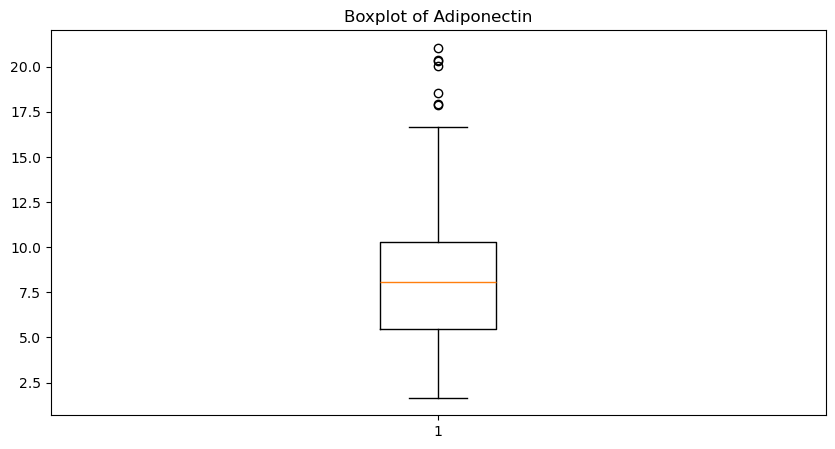

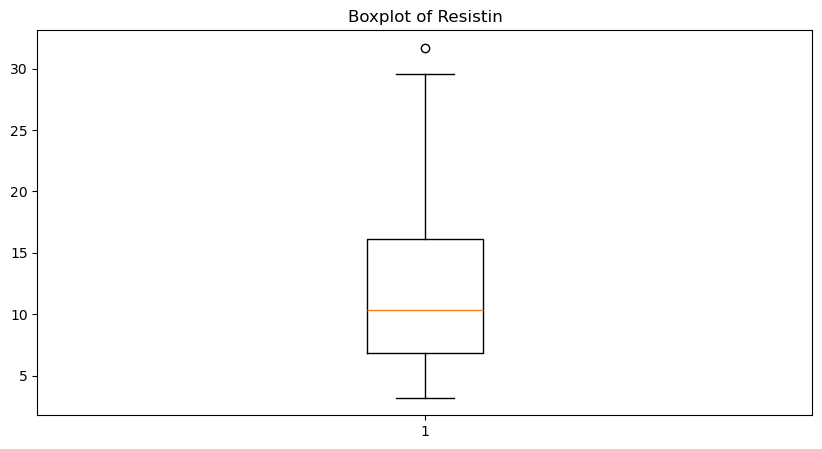

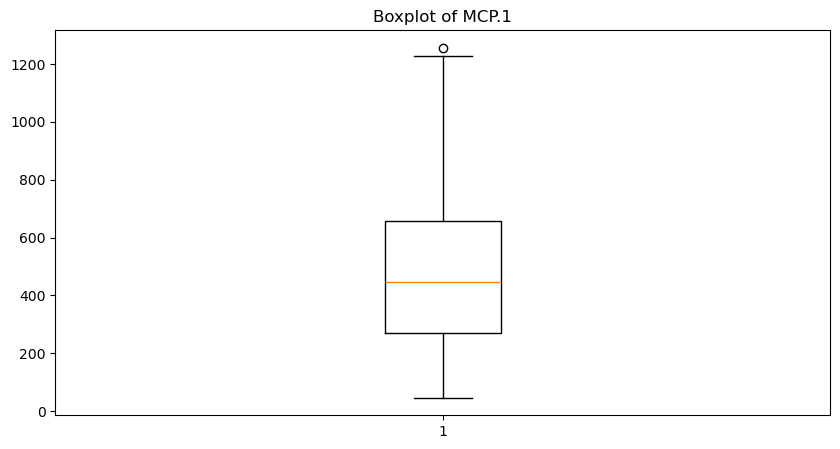

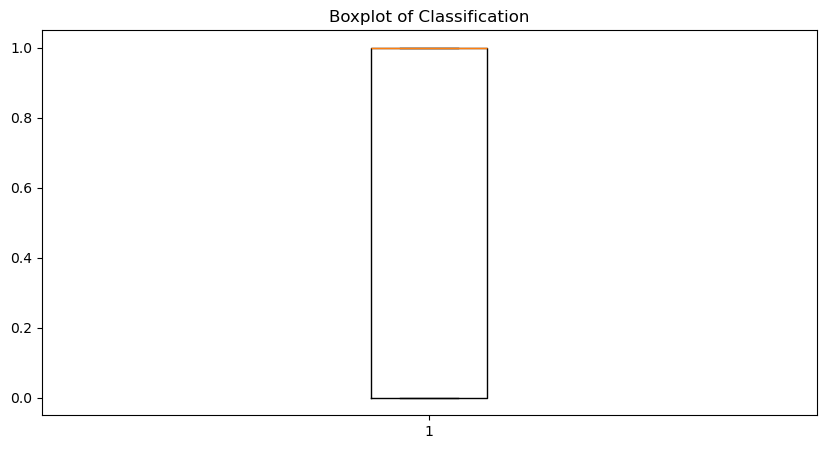

In [7]:
#check outliers 
for column in df.columns:
    plt.figure(figsize=(10, 5))
    plt.boxplot(df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

In [9]:
df.head()

,ID,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,1,48,23.500000,70.0,2.707,0.467409,8.8071,9.702400,7.99585,417.114,0
1,2,83,20.690495,92.0,3.115,0.706897,8.8438,5.429285,4.06405,468.786,0
2,3,82,23.124670,91.0,4.498,1.009651,17.9393,8.067775,9.27715,554.697,0
3,4,68,21.367521,77.0,3.226,0.612725,9.8827,7.169560,12.76600,928.220,0
4,5,86,21.111111,92.0,3.549,0.805386,6.6994,4.819240,10.57635,773.920,0


In [10]:
#train test split
from sklearn.model_selection import train_test_split
X = df.drop('Classification', axis=1)
y = df['Classification']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
#svc model
from sklearn.svm import SVC
model = SVC(kernel='rbf', random_state=42, C=1.0, gamma='scale')
model.fit(X_train, y_train)

SVC(random_state=42)

In [12]:
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("accuracy:", accuracy_score(y_test, y_pred))

accuracy: 0.5416666666666666
